# **Aplicação Knn**

Import de bibliotecas

In [ ]:
%pip install kneed
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
#import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#from sklearn.preprocessing import LabelEncoder
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.svm import SVC
#from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
#from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_score
#from kneed import KneeLocator
#from yellowbrick.cluster import SilhouetteVisualizer
#from itertools import combinations
#import plotly.express as px
#from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
#from kneed import knee_locator

Load do DF

In [3]:
# Carregando o dataset
df = pd.read_csv("../datasets/spotify_processed.csv")

KNn

In [6]:
# 1. Carregando
# Copiando o DF original
new_df = df.copy()

In [ ]:
# 2. Dividir em treino e teste
X = pd.concat([new_df.reset_index(drop=True), new_df.reset_index(drop=True)], axis=1)
y = new_df['is_popular']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# 3. Balanceamento com SMOTE no treino
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [14]:
# 4. GridSearchCV para KNN
param_grid = {
    'n_neighbors': list(range(3, 11, 2)),  # k ímpar de 3 a 9
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_bal, y_train_bal)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")

best_knn = grid_search.best_estimator_

Melhores parâmetros encontrados: {'n_neighbors': 3, 'weights': 'distance'}


Matriz de Confusão (Teste - KNN):
[[21455   299]
 [  207  2443]]


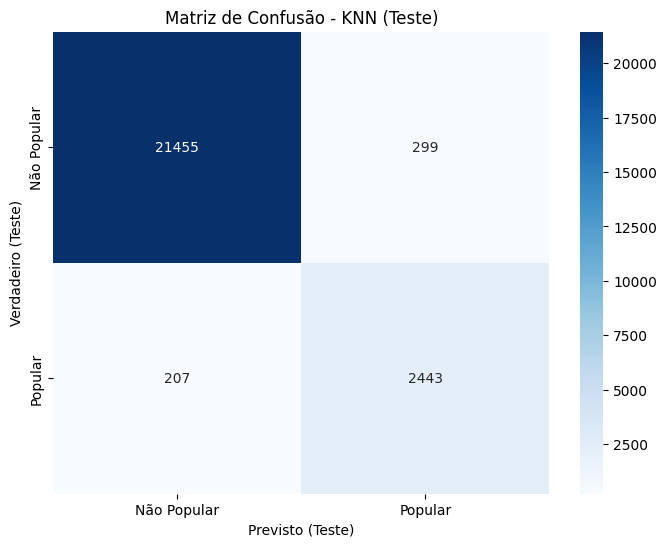


Métricas de Classificação (Teste - KNN):
              precision    recall  f1-score   support

 Não Popular       0.99      0.99      0.99     21754
     Popular       0.89      0.92      0.91      2650

    accuracy                           0.98     24404
   macro avg       0.94      0.95      0.95     24404
weighted avg       0.98      0.98      0.98     24404



In [16]:
# 5. Avaliação do conjunto de TESTE
# Usa o modelo KNN otimizado (best_knn) para fazer previsões no conjunto de teste
y_pred_knn_test = best_knn.predict(X_test)

# Calcula a matriz de confusão comparando os rótulos reais e os previstos no teste
conf_matrix_knn_test = confusion_matrix(y_test, y_pred_knn_test)
print("Matriz de Confusão (Teste - KNN):")
print(conf_matrix_knn_test)

# Cria uma figura para exibir graficamente a matriz de confusão do teste
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],   # Rótulos das classes previstas
            yticklabels=['Não Popular', 'Popular'])   # Rótulos das classes reais
plt.xlabel('Previsto (Teste)')                        # Eixo X: classe prevista
plt.ylabel('Verdadeiro (Teste)')                      # Eixo Y: classe real
plt.title('Matriz de Confusão - KNN (Teste)')         # Título do gráfico
plt.show()

# Exibe as métricas de desempenho: precisão, recall, F1-score e suporte
print("\nMétricas de Classificação (Teste - KNN):")
print(classification_report(y_test, y_pred_knn_test, target_names=['Não Popular', 'Popular']))


Matriz de Confusão (Treino - KNN):
[[50756     0]
 [    0  6184]]


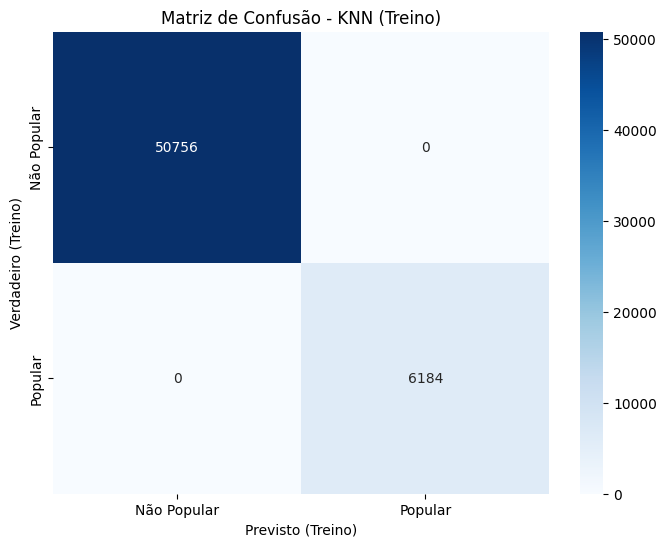


Métricas de Classificação (Treino - KNN):
              precision    recall  f1-score   support

 Não Popular       1.00      1.00      1.00     50756
     Popular       1.00      1.00      1.00      6184

    accuracy                           1.00     56940
   macro avg       1.00      1.00      1.00     56940
weighted avg       1.00      1.00      1.00     56940



In [18]:
# 6. Avaliação do conjunto de TREINO
# Usa o modelo KNN otimizado (best_knn) para prever no conjunto de treino
y_pred_knn_train = best_knn.predict(X_train)

# Calcula a matriz de confusão no conjunto de treino
conf_matrix_knn_train = confusion_matrix(y_train, y_pred_knn_train)
print("\nMatriz de Confusão (Treino - KNN):")
print(conf_matrix_knn_train)

# Plota a matriz de confusão do treino
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],   # Rótulos previstos
            yticklabels=['Não Popular', 'Popular'])   # Rótulos verdadeiros
plt.xlabel('Previsto (Treino)')                      # Eixo X: classe prevista
plt.ylabel('Verdadeiro (Treino)')                    # Eixo Y: classe real
plt.title('Matriz de Confusão - KNN (Treino)')       # Título do gráfico
plt.show()

# Exibe as métricas de desempenho no treino
print("\nMétricas de Classificação (Treino - KNN):")
print(classification_report(y_train, y_pred_knn_train, target_names=['Não Popular', 'Popular']))